In [1]:
import pickle
import pandas as pd 

import numpy as np 
import os 

In [2]:
import pickle


import scanpy as sc

import pandas as pd



import matplotlib.pyplot as plt
from matplotlib import colors
# color_map
# sc.settings.set_figure_params(dpi=120)

plt.rcParams['figure.figsize']=(8,8) #rescale figures
# sc.settings.verbosity = 3

sc.set_figure_params(scanpy=True, dpi_save=400,dpi=150)

plt.rcParams["font.family"] = "Arial"
plt.rcParams['pdf.fonttype'] = 42

In [3]:
sc.settings.figdir = '../fig4a_main_realslices'

In [4]:
figdir = '../fig4a_main_realslices'

## Fig 4a

In [5]:
adata_sc = sc.read("../../datasets/dataset12_xenium/data/scrna_ref_norm1knolog.h5ad")



In [6]:
adata_sc

AnnData object with n_obs × n_vars = 26031 × 307
    obs: 'celltype', 'n_counts', 'Anno'
    uns: 'Anno_colors', 'celltype_colors'
    obsm: 'X_tsne', 'X_umap'

In [7]:
sc.pl.tsne(adata_sc,color='Anno',title='scRNA tSNE',add_outline=True,frameon=False,legend_loc='on data',legend_fontoutline=2,legend_fontsize=12,show=False,save='_4a.pdf')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

<Axes: title={'center': 'scRNA tSNE'}, xlabel='tSNE1', ylabel='tSNE2'>

In [8]:
sc.pl.tsne(adata_sc,color='Anno',title='scRNA tSNE',add_outline=True,frameon=False,legend_loc='on data',legend_fontoutline=2,legend_fontsize=12,show=False,save='_4a.png')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

<Axes: title={'center': 'scRNA tSNE'}, xlabel='tSNE1', ylabel='tSNE2'>

## 4b

In [7]:

spa_celltype_key='Anno'

dataset = 'Janesick2023'

scrna_cluster_key = "Anno"

deconv_dir = figdir + dataset + '/deconv/'
metrics_dir = figdir + dataset + '/metrics/'

dataset_full = 'dataset12_xenium'

N = 50
nneigh = 10
nbdswaps = 2
par_lambda_curr = 0.1
# par_eta1_curr = 10.0
kernel3d_bw_slices_curr = 8
bandwidth_curr = 0.01
n_spatial_neigh_curr = 10
mode_nbd = 'variabletranscr'
gtalign = False # if True, use GT alignment 
aligntool = 'moscot'
key_name = 'linear_0'
num_augment = '20'
mode_nbd = 'variabletranscr'
augment = True
mode = 'multislice'
suffix = '_norm1knolog'



partesting_str =     '_partesting_' + 'parlambda_' + str(par_lambda_curr) + '_parbw_' + str(bandwidth_curr) + '_nbdtype_' + mode_nbd # + '_pareta1_' + str(par_eta1) +  '_3Dkernelbw_' + str(kernel3d_bw_slices_curr)

#### read spots from semi-simulated spatial file ######
adata_spa_path = '../../datasets/' + dataset_full + '/results/simulations/pickles/' + 'multi_slice_simulated_' + 'sptsz_' + str(N)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + suffix + '.pickle' # '_old.pickle'        
# read spatial file 
if not os.path.exists(adata_spa_path):
    sys.exit() 
with open(adata_spa_path, 'rb') as handle:
    adata_spa = pickle.load(handle)

/tmp/ipykernel_297128/922083272.py:40: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  adata_spa = pickle.load(handle)


In [14]:
adata_spa['linear_0'][9]

{0: AnnData object with n_obs × n_vars = 3201 × 307
     obs: 'BCells', 'DCs', 'Endothelial', 'Macrophages', 'Mast', 'Myoepithelial', 'Perivascular-Like', 'Stromal', 'TCells', 'Tumor'
     uns: 'spatial_neighbors'
     obsm: 'spatial',
 1: AnnData object with n_obs × n_vars = 2199 × 307
     obs: 'BCells', 'DCs', 'Endothelial', 'Macrophages', 'Mast', 'Myoepithelial', 'Perivascular-Like', 'Stromal', 'TCells', 'Tumor'
     uns: 'spatial_neighbors'
     obsm: 'spatial'}

In [10]:
# adata_sc = sc.read('../../datasets/' + dataset_full +   "/data/scrna_ref" + suffix + ".h5ad")

cell_type = scrna_cluster_key
celltype_colors = list(adata_sc.uns[cell_type + '_colors'])
celltype_classes  = list(adata_sc.obs[cell_type].cat.categories)


## Fig 4b

In [11]:

spa_celltype_key='Anno'

dataset = 'Janesick2023'

scrna_cluster_key = "Anno"

deconv_dir = figdir  + '/deconv/'
metrics_dir = figdir  + '/metrics/'


N = 50
nneigh = 10
nbdswaps = 2
par_lambda_curr = 0.1
# par_eta1_curr = 10.0
kernel3d_bw_slices_curr = 8
bandwidth_curr = 0.01
n_spatial_neigh_curr = 10
mode_nbd = 'variabletranscr'
gtalign = False # if True, use GT alignment 
aligntool = 'moscot'
key_name = 'linear_0'
num_augment = '20'
mode_nbd = 'variabletranscr'
augment = True
mode = 'multislice'

# _gtalign_False_augment_True_kernel3d_bw_slices_8_num_augment_20_

partesting_str =     '_partesting_' + 'parlambda_' + str(par_lambda_curr) +   '_parbw_' + str(bandwidth_curr) +  '_nbdtype_' + mode_nbd +  '_gtalign_' + str(gtalign) + '_augment_' + str(augment) + '_kernel3d_bw_slices_' + str(kernel3d_bw_slices_curr) + '_num_augment_' + str(num_augment) + '_realalign_' + str(aligntool) 
res_file = 'metrics_' + mode + '_' + mode_nbd + '_sptsz_' + str(N)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + partesting_str +'_sc.pickle'
print(res_file)
with open(metrics_dir + res_file, 'rb') as handle:
    metrics_sc_ms = pickle.load(handle)


res_file = 'metrics_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_CARD.pickle'
with open(metrics_dir + res_file, 'rb') as handle:
    metrics_card = pickle.load(handle)
metrics_card = metrics_card['linear_0']

res_file = 'metrics_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_cell2location.pickle'
if os.path.exists(metrics_dir + res_file):
    with open(metrics_dir + res_file, 'rb') as handle:
        metrics_cell2loc = pickle.load(handle)
    metrics_cell2loc = metrics_cell2loc['linear_0']
else:
    metrics_cell2loc = metrics_card.copy()

res_file = 'metrics_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_tangram.pickle'
with open(metrics_dir + res_file, 'rb') as handle:
    metrics_tangram = pickle.load(handle)
metrics_tangram = metrics_tangram['linear_0']

res_file = 'metrics_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_tangramsc.pickle'
with open(metrics_dir + res_file, 'rb') as handle:
    metrics_tangramsc = pickle.load(handle)
metrics_tangramsc = metrics_tangramsc['linear_0']




all_algos =  {
              'SpaDecoder':metrics_sc_ms,
                'CARD':metrics_card,
                'Cell2location':metrics_cell2loc,
                'Tangram':metrics_tangram,
                'Tangramsc':metrics_tangramsc,
                }


result_metrics = ['orig_rmse_avg',  'avg_corr_pe_avg', 'avg_jsd_avg']
col_names = result_metrics.copy()
col_names.extend(['algo'])
res_df = pd.DataFrame(columns=col_names)
idx = 0



for algo_name, algo_res in all_algos.items():
    real_samp = list(algo_res.keys())
    # sim_samp = metrics_sc_ms[entry][real_samp[0]].keys()
    for real_samp_name in real_samp:

        tmp_df = algo_res[real_samp_name].loc[result_metrics,:].T
        tmp_df['algo'] = algo_name
        tmp_df['sample'] = real_samp_name
        res_df = pd.concat([res_df,tmp_df])


        
res_df['dataset'] = 'Janesick2023'

/tmp/ipykernel_1826824/3153287022.py:34: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  metrics_sc_ms = pickle.load(handle)
/tmp/ipykernel_1826824/3153287022.py:39: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If t

metrics_multislice_variabletranscr_sptsz_50_nneigh_10_nbdswaps_2_partesting_parlambda_0.1_parbw_0.01_nbdtype_variabletranscr_gtalign_False_augment_True_kernel3d_bw_slices_8_num_augment_20_realalign_moscot_sc.pickle


In [12]:
to_plot = ['SpaDecoder', 'CARD', 'Cell2location', 'Tangram', 'Tangramsc']


In [13]:
res_df['simidx'] = res_df.index

In [14]:
res_df = res_df[res_df['simidx'] == 0]

In [15]:
figdir = '../fig4a_main_realslices/'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def grouped_barplot(df, group_col, category_col, group_order, algo_order, value_col, save_path=None, xlabel="Groups", ylabel="Value", title="Grouped Bar Plot"):
    """
    Creates a grouped barplot where one column indicates the group, and another column represents categories within the group.
    The mean value is plotted as the height of the bars, and the standard deviation is used for error bars.

    Parameters:
    - df: Input DataFrame with values.
    - group_col: Column name representing groups.
    - category_col: Column name representing categories within groups.
    - value_col: Column name containing the values to be plotted.
    - xlabel: Label for the x-axis.
    - ylabel: Label for the y-axis.
    - title: Plot title.
    """

    # Compute mean and standard deviation for each (group, category) combination
    summary_df = df.groupby([group_col, category_col])[value_col].agg(['mean', 'min','max']).reset_index()

    # Handle NaN standard deviation values by replacing them with 0
    # summary_df['std'] = summary_df['std'].fillna(0)

    # Get unique groups and categories
    groups = group_order #summary_df[group_col].unique()
    categories = algo_order #summary_df[category_col].unique()

    # Define bar width and spacing
    bar_width = 0.001  # Width of each bar
    group_spacing = 0.001  # Space between groups
    x = np.arange(len(groups)) * (len(categories) * bar_width + group_spacing)

    fig, ax = plt.subplots(figsize=(4, 4))

    # Plot bars for each category
    for i, category in enumerate(categories):
        subset = summary_df[summary_df[category_col] == category].copy()
        subset[group_col] = pd.Categorical(subset[group_col], categories=group_order, ordered=True)
        subset = subset.sort_values(by=group_col)
        
        x_positions = x + i * bar_width
        means = subset['mean'].values
        # errors = subset['std'].values  # Standard deviation as error bars
        y_err = np.stack([subset['mean'].values - subset['min'].values, subset['max'].values - subset['mean'].values])
        # print(errors)
        # print(x_positions)
        # print(means)
        ax.bar(
            x_positions,
            means,
            bar_width,
            yerr=y_err,
            capsize=5,
            label=category
        )


        # Annotate each bar with its mean value
        for xpos, mean, err in zip(x_positions, means, y_err.T):
            # Adjust the offset (0.01) as needed for clarity.
            ax.text(xpos, mean + err[1] + 0.001, f'{mean:.4f}', ha='center', va='bottom', fontsize=12)


    # Customize x-axis
    ax.set_xticks(x + bar_width * (len(categories) - 1) / 2)
    ax.set_xticklabels(groups, rotation=0, fontsize=24)
    ax.tick_params(axis='y', labelsize=24)

    # Add labels, title, and legend
    # ax.set_xlabel(xlabel, fontsize=24)
    ax.set_ylabel(ylabel, fontsize=24)
    # ax.set_title(title, fontsize=24)
    # ax.legend(title="Categories", fontsize=24, title_fontsize=14,loc='upper left', bbox_to_anchor=(1.02, 1))
    # ax.tick_params(axis='x', labelrotation=45)
    # Adjust layout and show plot
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=1200, bbox_inches='tight')
    plt.show()


dataset_curr = 'Janesick2023'
# df = pd.DataFrame(data)
# dataset_newname = {  'Moffitt2018':'Moffitt2018','Choi2023':'Choi2023',# 'dataset3_seqfishpluscai':'Eng2019No.2', 
#                     # 'dataset4_seqfishpluscai':'Eng2019',  'dataset5_starmap_mousevisualcortex':'Wang2018', 
#                     'Haviv2025':'Haviv2025'}
dataset = [  dataset_curr ]# 'Moffitt2018-high',
          #  'Choi2023',# 'Choi2023-high',# 'dataset3_seqfishpluscai', 'dataset4_seqfishpluscai',  'dataset5_starmap_mousevisualcortex',
           #  'Haviv2025']# 'Haviv2025-high']
result_metric_newname = {'orig_rmse_avg':'RMSE','avg_corr_pe_avg':'Aver Corr','avg_jsd_avg':'Aver JSD'}

# Plot using the function
# for metric in result_metrics:
#     grouped_barplot(res_df3, group_col="dataset", category_col="algo", group_order=list(dataset_newname.values()),algo_order=list(all_algos.keys()), value_col=metric,xlabel='Methods Across Datasets',ylabel=result_metric_newname[metric],title=result_metric_newname[metric] + ' Metric')

# res_df_tmp = res_df[res_df['dataset']=='Haviv2025']
for metric in result_metrics:
    grouped_barplot(res_df, group_col="dataset", category_col="algo", group_order=dataset,algo_order=to_plot, save_path=figdir + metric + '.pdf',value_col=metric,xlabel='Datasets',ylabel=result_metric_newname[metric],title= dataset_curr)
    # plt.savefig(*args 

In [17]:
res_df.to_csv(figdir + 'metrics_summary.csv')

## pie plots for SpaDecoder and othe tools 

In [21]:

def viz_slice_spots_one(adata, celltype_classes, celltype_colors, legend=True, title="Tissue Slice Visualization"):
    # Ensure that the required celltype columns exist in adata.obs
    

    # fig, axs = plt.subplots(1, 1, figsize=(20, 18))

    # if hasattr(axs, "flatten"):
    #     axs = axs.flatten()
    # else:
    #     axs = [axs]

    # Reorder the cell types in adata.obs
    legend_handles = None
    assert set(adata.obs.columns) == set(celltype_classes)
    adata.obs = adata.obs[celltype_classes]
    assert list(adata.obs.columns) == celltype_classes
    # ax = axs[j]
    

    # Create a plot with subplots
    N = 1  # Only one object, so N = 1
    n_rows = 1
    n_cols = 1
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 16))


    
    # Plot each point as a pie chart for the single Scanpy object (adata)
    for i in range(adata.obs.shape[0]):
        # Add a pie chart at each (x, y) position
        pie_size = 0.008  # Size of each pie chart
        cell_name = adata.obs.index[i]
        wedges, _ = ax.pie(
            adata.obs.loc[cell_name,].values,
            center=(adata.obsm['spatial'][i, 0], adata.obsm['spatial'][i, 1]),
            radius=pie_size, colors=celltype_colors,
            wedgeprops={"linewidth": 0, "edgecolor": "none"}
        )

    # Set axis limits based on spatial data
    mina = adata.obsm['spatial'].min(axis=0)
    maxa = adata.obsm['spatial'].max(axis=0)
    ax.set_xlim(mina[0], maxa[0])
    ax.set_ylim(mina[1] - 0.06, maxa[1] + 0.06)

    # Add title and other settings
    ax.set_title(title, fontsize=24)
    ax.set_aspect('equal')

    if legend:
        fig.subplots_adjust(right=0.85)
        fig.legend(
            handles=wedges,
            labels=celltype_classes,
            title="CellTypes",
            loc="center left",
            bbox_to_anchor=(0.9, 0.5),
            fontsize=10,
            title_fontsize=20
        )

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    return fig



findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

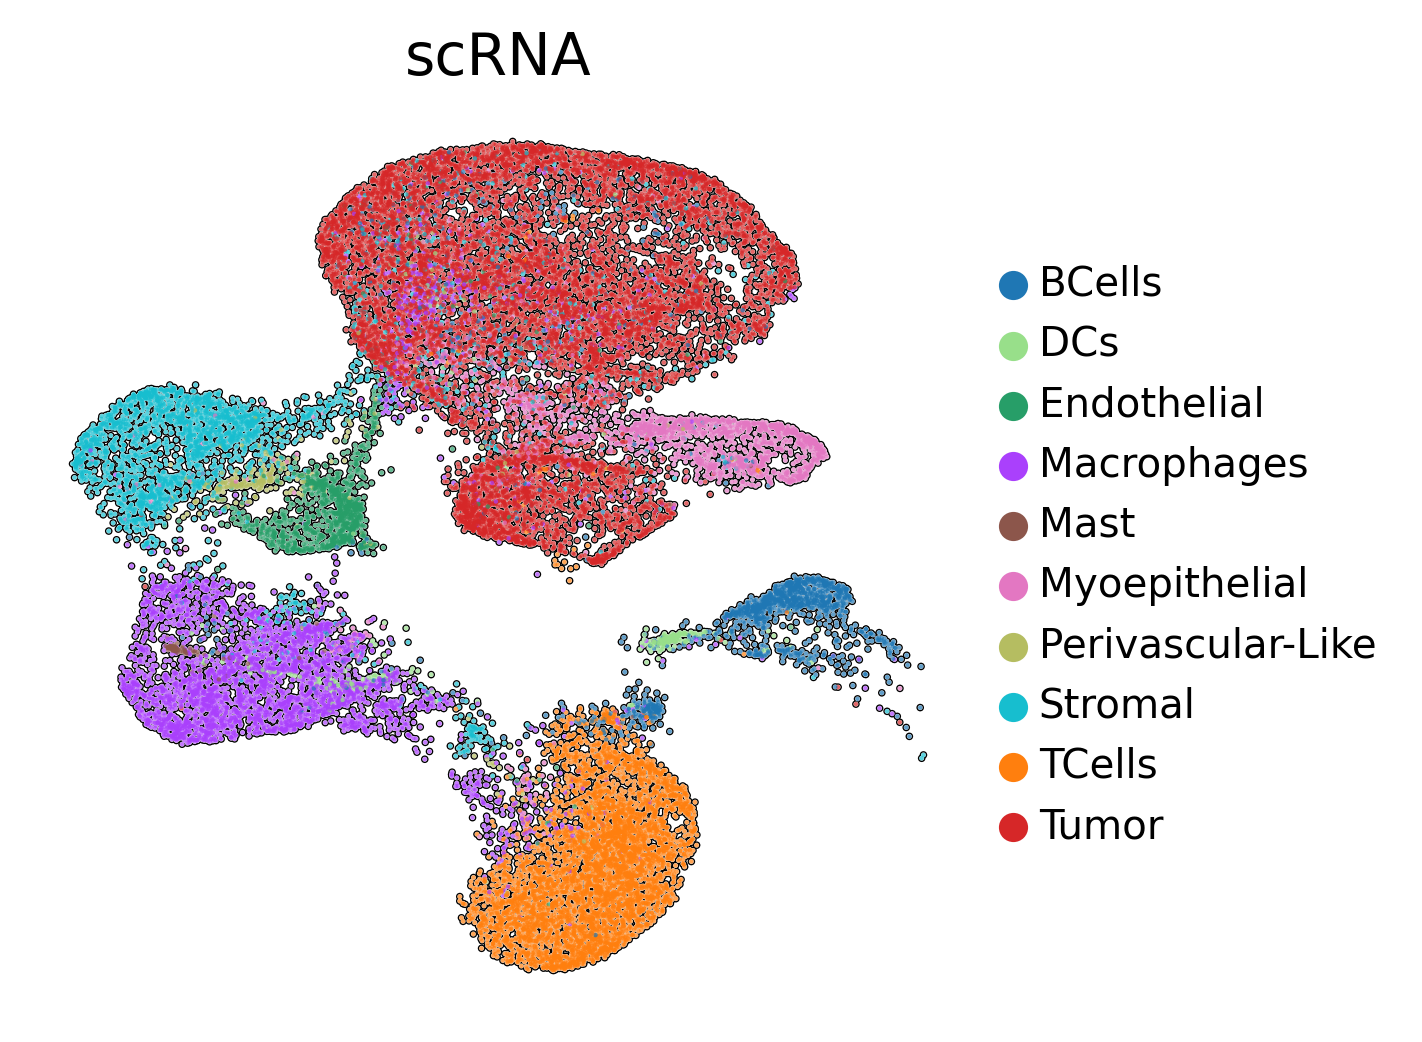

/tmp/ipykernel_1826824/3232636591.py:59: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  adata_spa = pickle.load(handle)
/tmp/ipykernel_1826824/3232636591.py:104: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that

In [22]:
spa_celltype_key='Anno'

dataset = '12'


# spa_celltype_key='celltype'


scrna_cluster_key = "Anno"

datasetdir = '../' # 'dataset4_seqfishpluscai'
# adata_sc = sc.read(datasetdir + "/data/scrnaseq_raw.h5ad")
# adata_sc = sc.read(datasetdir + "data/scrna_ref_norm1knolog.h5ad")
# common_celltypes  = ['Olfactory ensheathing cells',
#  'Mitral/Tufted cells',
#  'Neuroblasts',
#  'Oligodendrocytes',
#  'Interneurons',
#  'Astrocytes',
#  'Microglia',
#  'Endothelial'] 


sc.pl.umap(adata_sc, add_outline=True, legend_fontsize='x-small',frameon=False,color=scrna_cluster_key,title='scRNA',save='_scRNAcelltypes.png')


cell_type = scrna_cluster_key
celltype_colors = list(adata_sc.uns[cell_type + '_colors'])
celltype_classes  = list(adata_sc.obs[cell_type].cat.categories)

# simdir = datasetdir + '/results/simulations/pickles/'
# basedir = datasetdir + '/results/simulations/slice_warps/'

suffix = '_norm1knolog'

numeta = len(celltype_classes)



N = 50
nneigh = 10
nbdswaps = 2
par_lambda = 0.1
par_bw = 0.01
augment = True
gt_align = False
kernel3d_bw_slices = 8
bandwidth = 0.01 
num_augment = 20

adata_spa_path = figdir  + '/multi_slice_simulated_' + 'sptsz_' + str(N)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + suffix + '.pickle' # '_old.pickle'

key_name = 'linear_0'

result_metric = ['orig_rmse',   'avg_corr_pe','avg_jsd']

# ground truth 
with open(adata_spa_path, 'rb') as handle:
    adata_spa = pickle.load(handle)

# SpaDecoder-SingleSlice
# mode = 'singleslice'
# mode_nbd = 'variabletranscr'
# aligntool = 'moscot'
# partesting = '_partesting_parlambda_' + str(par_lambda) + '_parbw_' + str(par_bw) + '_' + 'nbdtype_' + mode_nbd + '_realalign_' + aligntool
# res_file = 'deconv_' + mode + '_' + mode_nbd + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + partesting + '_sc.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     deconv_ss = pickle.load(handle)

# mode = 'singleslice'
# mode_nbd = 'variabletranscr'
# aligntool = 'moscot'
# partesting = '_partesting_parlambda_' + str(par_lambda) + '_parbw_' + str(par_bw) + '_' + 'nbdtype_' + mode_nbd + '_realalign_' + aligntool
# res_file = 'deconv_' + mode + '_' + mode_nbd + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + partesting + '_cluster.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     deconv_ss_cluster = pickle.load(handle)

# # SpaDecoder-Multislice
# mode = 'multislice'
# mode_nbd = 'variabletranscr'
# aligntool = 'moscot'
# partesting = '_partesting_parlambda_' + str(par_lambda) + '_parbw_' + str(par_bw) + '_' + 'nbdtype_' + mode_nbd + '_realalign_' + aligntool
# res_file = 'deconv_' + mode + '_' + mode_nbd + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + partesting + '_cluster.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     deconv_ms_clus = pickle.load(handle)


# mode = 'multislice'
# mode_nbd = 'variabletranscr'
# aligntool = 'moscot'
# partesting = '_partesting_parlambda_' + str(par_lambda) + '_parbw_' + str(par_bw) + '_' + 'nbdtype_' + mode_nbd + '_realalign_' + aligntool
# res_file = 'deconv_' + mode + '_' + mode_nbd + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + partesting + '_sc.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     deconv_ms_sc = pickle.load(handle)


mode = 'multislice'
mode_nbd = 'variabletranscr'
aligntool = 'moscot'
# partesting = '_partesting_parlambda_' + str(par_lambda) + '_parbw_' + str(par_bw) + '_' + 'nbdtype_' + mode_nbd + '_realalign_' + aligntool
partesting =  '_partesting_' + 'parlambda_' + str(par_lambda) + '_parbw_' + str(bandwidth) + '_nbdtype_' + mode_nbd + '_gtalign_' + str(gt_align) + '_augment_' + str(augment) + '_kernel3d_bw_slices_' + str(kernel3d_bw_slices) + '_num_augment_' + str(num_augment) + '_realalign_' + aligntool # + '_pareta1_' + str(par_eta1) +  '_3Dkernelbw_' + str(kernel3d_bw_slices_curr)
res_file = 'deconv_' + mode + '_' + mode_nbd + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + partesting + '_sc.pickle' 
with open(figdir + '/deconv/' + res_file, 'rb') as handle:
    deconv_ms = pickle.load(handle)
# mode = 'multislice'
# mode_nbd = 'variabletranscr'
# aligntool = 'moscot'
# partesting = '_partesting_parlambda_' + str(par_lambda) + '_parbw_' + str(par_bw) + '_' + 'nbdtype_' + mode_nbd + '_realalign_' + aligntool
# res_file = 'deconv_' + mode + '_' + mode_nbd + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + partesting + '_cluster.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     deconv_ms_cluster = pickle.load(handle)

# # Multi-SpaDecoder-Cluster
# mode = 'multislice'
# res_file = 'deconv_' + mode + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_cluster.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     metrics_bulk_ms = pickle.load(handle)


# # Multi-SpaDecoder-Singlecell
# mode = 'multislice'
# res_file = 'deconv_' + mode + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_singlecell.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     metrics_sc_ms = pickle.load(handle)



# # Multi-SpaDecoder-Cluster-NoMid
# mode = 'multislice'
# res_file = 'deconv_' + mode + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_cluster_nomid.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     metrics_bulk_ms_nomid = pickle.load(handle)

# # Multi-SpaDecoder-Singlecell-NoMid
# mode = 'multislice'
# res_file = 'deconv_' + mode + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_singlecell_nomid.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     metrics_sc_ms_nomid = pickle.load(handle)


# # Multi-SpaDecoder-Cluster-NoMid
# mode = 'multislice'
# res_file = 'deconv_' + mode + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_cluster_nbd.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     metrics_bulk_ms_nbd = pickle.load(handle)

# # Multi-SpaDecoder-Singlecell-NoMid
# mode = 'multislice'
# res_file = 'deconv_' + mode + '_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_singlecell_nbd.pickle' 
# with open(basedir + res_file, 'rb') as handle:
#     metrics_sc_ms_nbd = pickle.load(handle)



## Tangram-sc
res_file = 'deconv_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_tangramsc.pickle'
with open(figdir + '/deconv/' + res_file, 'rb') as handle:
    deconv_tangramsc= pickle.load(handle)
deconv_tangramsc = deconv_tangramsc['linear_0']


## Tangram-bulk
res_file = 'deconv_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_tangram.pickle'
with open(figdir + '/deconv/' +res_file, 'rb') as handle:
    deconv_tangram = pickle.load(handle)
deconv_tangram = deconv_tangram['linear_0']
# Cell2location
res_file = 'deconv_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_cell2location.pickle'
with open(figdir + '/deconv/' + res_file, 'rb') as handle:
    deconv_cell2loc = pickle.load(handle)
deconv_cell2loc = deconv_cell2loc['linear_0']
## CARD 
res_file = 'deconv_st1_sptsz_' + str(N) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + '_CARD.pickle'
with open(figdir + '/deconv/' + res_file, 'rb') as handle:
    deconv_card = pickle.load(handle)
deconv_card = deconv_card['linear_0']



In [23]:
key_name = 'linear_0'

all_algos =  {'GroundTruth':adata_spa,
              # 'SpaDecoder-Cluster':metrics_bulk,
              # 'SpaDecoder-Singlecell':metrics_sc,

              # 'SingleSlice-SpaDecoder':deconv_ss,
              #  'SingleSlice-SpaDecoder-Clus':deconv_ss_cluster,
              'SpaDecoder':deconv_ms,
              # 'Multi-SpaDecoder-Clus':deconv_ms_clus,
              #   'Multi-SpaDecoder-Orig':deconv_ms_orig,

              # 'Multi-SpaDecoder-Cluster-NoMid':metrics_bulk_ms_nomid,
              # 'Multi-SpaDecoder-Singlecell-NoMid':metrics_sc_ms_nomid,
              
            #   'Multi-SpaDecoder-Cluster-Nbd':metrics_bulk_ms_nbd,
            #   'Multi-SpaDecoder-Singlecell-Nbd':metrics_sc_ms_nbd,

              'Tangramsc':deconv_tangramsc,
              'Tangram':deconv_tangram,
              'Cell2location':deconv_cell2loc,
              'CARD':deconv_card}




In [24]:
figdir

'../fig4a_main_realslices/'

In [26]:




from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

dataset = '12'
# output_pdf = "./figures/viz_slices_deconv_output_dataset_" + dataset + "_individuals.pdf"


# with PdfPages(output_pdf) as pdf:

for realidx in deconv_ms.keys(): # real slice 
    for simidx in [0]:#metrics_card['linear_0'][realidx].keys(): # sim slice 
        adata_dict = {}
        for algo_name in all_algos.keys():
            if algo_name != 'GroundTruth':
                adata_dict[algo_name + 'Sample:' + str(realidx) + 'Sim:' + str(simidx)] = all_algos['GroundTruth']['linear_0'][simidx][realidx].copy()
                adata_dict[algo_name + 'Sample:' + str(realidx) + 'Sim:' + str(simidx)].obs = all_algos[algo_name][realidx][simidx].T
            else:
                adata_dict[algo_name + 'Sample:' + str(realidx) + 'Sim:' + str(simidx)] = all_algos['GroundTruth']['linear_0'][simidx][realidx].copy()
                # print(adata_dict[algo_name + 'Sample:' + str(realidx) + 'Sim:' + str(simidx)])
            fig = viz_slice_spots_one(adata_dict[algo_name + 'Sample:' + str(realidx) + 'Sim:' + str(simidx)],celltype_classes,celltype_colors,legend=True,title=algo_name + ' Slice: ' + str(realidx) )

            fig_path = figdir + "/viz_slices_deconv_output_dataset_" + dataset + "_algo_" + algo_name + "_realslice_" + str(realidx) + "_simslice_" + str(simidx) + "_individuals.pdf"
            fig.savefig(fig_path, dpi=400, bbox_inches='tight')
            plt.close(fig)

                

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f